This is a Jupyter notebook for analyzing the Olist Brazilian E-commerce dataset.
Practicing in python with pandas and SQL to prepare for Elevate technical assessment. Working with Claude Code and visualizing in Windsurf.

<img src="olist_schema.png" width="700"/>

The Fictional Brief:
Elevate Portfolio Analytics — Olist Integration Project
Olist is a Brazilian e-commerce marketplace that connects small merchants to major retail channels. Your client, a PE firm, has acquired three regional merchant clusters operating on Olist's platform. Each cluster has its own sellers, customers, and order history. Your job is to unify and analyze the combined dataset to surface operational insights and flag data quality issues — exactly the kind of integration and BI work Elevate does across its roll-up companies.

Build Plan:

Phase 1 — Ingestion & Schema Mapping (Python/pandas)
Load all CSVs, inspect shapes and dtypes, identify primary and foreign keys across tables. Document your schema as a markdown cell with a simple entity map.

Phase 2 — Data Quality Audit (Python + DuckDB)
Use DuckDB to query across the CSVs with SQL — find nulls, duplicate keys, orphaned order items with no matching order, reviews with no matching customer. This is your integration QA layer.

Phase 3 — Core Joins & Feature Engineering (DuckDB SQL)
Build your master analytical table by joining orders → order_items → products → sellers → customers → reviews → payments. Add derived columns: delivery delay in days, a binary late/on-time flag, GMV per order.

Phase 4 — Seller Scorecard (pandas)
Aggregate to seller level: total GMV, order count, avg review score, late delivery rate. Rank and segment sellers into tiers.

Phase 5 — Visualizations (matplotlib/seaborn)
At minimum: a GMV concentration curve (Pareto), a delivery delay vs. review score scatter, and a regional heatmap by seller state.

Phase 6 — Written Summary
A markdown cell at the end stating your findings, which hypotheses held, which didn't, and what you'd recommend to the client.

## Phase 1 — Load, Inspect & Map Schema

In [63]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path(".")

In [64]:
tables = {
    "orders":        pd.read_csv(DATA_DIR / "olist_orders_dataset.csv"),
    "order_items":   pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv"),
    "order_reviews": pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv"),
    "customers":     pd.read_csv(DATA_DIR / "olist_customers_dataset.csv"),
    "payments":      pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv"),
    "products":      pd.read_csv(DATA_DIR / "olist_products_dataset.csv"),
    "sellers":       pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv"),
    "geo":           pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv"),
    "category_xlat": pd.read_csv(DATA_DIR / "product_category_name_translation.csv"),
}
print("Loaded tables:", list(tables.keys()))

Loaded tables: ['orders', 'order_items', 'order_reviews', 'customers', 'payments', 'products', 'sellers', 'geo', 'category_xlat']


### Shape & Dtype Inspection

For each table: row/column counts, column dtypes, null counts, null %, and cardinality.

In [65]:
for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f"TABLE: {name}  —  {df.shape[0]:,} rows × {df.shape[1]} cols")
    summary = pd.DataFrame({
        "dtype":    df.dtypes,
        "nulls":    df.isnull().sum(),
        "null_%":   (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    display(summary)


TABLE: orders  —  99,441 rows × 8 cols


,dtype,nulls,null_%,n_unique
order_id,str,0,0.00,99441
customer_id,str,0,0.00,99441
order_status,str,0,0.00,8
order_purchase_timestamp,str,0,0.00,98875
order_approved_at,str,160,0.16,90733
order_delivered_carrier_date,str,1783,1.79,81018
order_delivered_customer_date,str,2965,2.98,95664
order_estimated_delivery_date,str,0,0.00,459



TABLE: order_items  —  112,650 rows × 7 cols


,dtype,nulls,null_%,n_unique
order_id,str,0,0.00,98666
order_item_id,int64,0,0.00,21
product_id,str,0,0.00,32951
seller_id,str,0,0.00,3095
shipping_limit_date,str,0,0.00,93318
price,float64,0,0.00,5968
freight_value,float64,0,0.00,6999



TABLE: order_reviews  —  99,224 rows × 7 cols


...

,dtype,nulls,null_%,n_unique
seller_id,str,0,0.00,3095
seller_zip_code_prefix,int64,0,0.00,2246
seller_city,str,0,0.00,611
seller_state,str,0,0.00,23



TABLE: geo  —  1,000,163 rows × 5 cols


,dtype,nulls,null_%,n_unique
geolocation_zip_code_prefix,int64,0,0.00,19015
geolocation_lat,float64,0,0.00,717363
geolocation_lng,float64,0,0.00,717615
geolocation_city,str,0,0.00,8011
geolocation_state,str,0,0.00,27



TABLE: category_xlat  —  71 rows × 2 cols


,dtype,nulls,null_%,n_unique
product_category_name,str,0,0.00,71
product_category_name_english,str,0,0.00,71


### Schema Relationship Map

```
orders (order_id PK, customer_id FK → customers.customer_id)
  ├─ order_items   (order_id FK, product_id FK → products, seller_id FK → sellers)
  ├─ payments      (order_id FK)
  └─ order_reviews (order_id FK)

customers    (customer_id PK, customer_zip_code_prefix → geo)
sellers      (seller_id PK,   seller_zip_code_prefix   → geo)
products     (product_id PK,  product_category_name FK → category_xlat)
geo          (geolocation_zip_code_prefix — NOT a unique PK; multiple lat/lng per zip)
category_xlat(product_category_name PK,  product_category_name_english)
```

**Cluster key** — `sellers.seller_state`:

| State | Cluster   |
|-------|-----------|
| SP    | Cluster A |
| RJ    | Cluster B |
| MG    | Cluster C |

**FK → PK reference table**

| Child table   | FK column                   | Parent table  | PK column                          |
|---------------|-----------------------------|---------------|------------------------------------|
| orders        | customer_id                 | customers     | customer_id                        |
| order_items   | order_id                    | orders        | order_id                           |
| order_items   | seller_id                   | sellers       | seller_id                          |
| order_items   | product_id                  | products      | product_id                         |
| payments      | order_id                    | orders        | order_id                           |
| order_reviews | order_id                    | orders        | order_id                           |
| products      | product_category_name       | category_xlat | product_category_name              |
| customers     | customer_zip_code_prefix    | geo           | geolocation_zip_code_prefix (non-unique) |
| sellers       | seller_zip_code_prefix      | geo           | geolocation_zip_code_prefix (non-unique) |

### Referential Integrity Checks

Verify FK → PK joins across all core relationships. Large orphan counts flag data quality gaps worth investigating in later phases.

In [66]:
checks = {
    "order_items.order_id   → orders":    (tables["order_items"]["order_id"],
                                            tables["orders"]["order_id"]),
    "order_items.seller_id  → sellers":   (tables["order_items"]["seller_id"],
                                            tables["sellers"]["seller_id"]),
    "order_items.product_id → products":  (tables["order_items"]["product_id"],
                                            tables["products"]["product_id"]),
    "orders.customer_id     → customers": (tables["orders"]["customer_id"],
                                            tables["customers"]["customer_id"]),
    "payments.order_id      → orders":    (tables["payments"]["order_id"],
                                            tables["orders"]["order_id"]),
    "reviews.order_id       → orders":    (tables["order_reviews"]["order_id"],
                                            tables["orders"]["order_id"]),
    "products.category      → xlat":      (tables["products"]["product_category_name"].dropna(),
                                            tables["category_xlat"]["product_category_name"]),
}

print(f"{'Relationship':<45}  {'Orphans':>10}  {'Total FK':>10}  {'Orphan %':>9}")
print("-" * 80)
for label, (fk_col, pk_col) in checks.items():
    orphans = (~fk_col.isin(pk_col)).sum()
    total   = len(fk_col)
    pct     = orphans / total * 100 if total else 0
    flag    = " ⚠️" if orphans > 0 else ""
    print(f"{label:<45}  {orphans:>10,}  {total:>10,}  {pct:>8.2f}%{flag}")

Relationship                                      Orphans    Total FK   Orphan %
--------------------------------------------------------------------------------
order_items.order_id   → orders                         0     112,650      0.00%
order_items.seller_id  → sellers                        0     112,650      0.00%
order_items.product_id → products                       0     112,650      0.00%
orders.customer_id     → customers                      0      99,441      0.00%
payments.order_id      → orders                         0     103,886      0.00%
reviews.order_id       → orders                         0      99,224      0.00%
products.category      → xlat                          13      32,341      0.04% ⚠️


### Cluster Assignment

Tag each seller by state → cluster label. This is the segmentation key for all downstream analysis.

In [67]:
CLUSTER_MAP = {"SP": "Cluster A", "RJ": "Cluster B", "MG": "Cluster C"}

sellers = tables["sellers"].copy()
sellers["cluster"] = sellers["seller_state"].map(CLUSTER_MAP).fillna("Other")
tables["sellers"] = sellers  # update shared dict for downstream use

cluster_counts = sellers["cluster"].value_counts().rename_axis("cluster").reset_index(name="seller_count")
cluster_counts["pct"] = (cluster_counts["seller_count"] / cluster_counts["seller_count"].sum() * 100).round(1)
display(cluster_counts)

,cluster,seller_count,pct
0,Cluster A,1849,59.70
1,Other,831,26.80
2,Cluster C,244,7.90
3,Cluster B,171,5.50


## Phase 2 — Data Quality Audit (DuckDB)

We register the pandas DataFrames from Phase 1 as DuckDB views, then run SQL checks against them.
DuckDB is an in-process OLAP engine — no server, no setup, works directly on in-memory DataFrames.

**Checks in this phase:**
1. DuckDB setup & view registration
2. Duplicate primary key detection
3. NULL audit on key columns
4. Orphaned record checks (LEFT JOIN + WHERE IS NULL pattern)
5. Payment anomalies
6. QA summary report (PASS / WARN)

In [68]:
import duckdb

con = duckdb.connect()
for name, df in tables.items():
    con.register(name, df)

registered = con.execute("SHOW TABLES").df()["name"].tolist()
print("DuckDB views registered:", registered)

DuckDB views registered: ['category_xlat', 'customers', 'geo', 'order_items', 'order_reviews', 'orders', 'payments', 'products', 'sellers']


### 1. Duplicate Primary Key Detection

Duplicate PKs would silently fan-out rows in every downstream join, inflating counts and GMV.
Pattern: `COUNT(*) - COUNT(DISTINCT pk_col)` — any non-zero result is a problem.

In [69]:
pk_checks = [
    ("orders",    "order_id"),
    ("customers", "customer_id"),
    ("sellers",   "seller_id"),
    ("products",  "product_id"),
    ("category_xlat", "product_category_name"),
]

rows = []
for table, pk_col in pk_checks:
    result = con.execute(f"""
        SELECT
            '{table}'  AS table_name,
            '{pk_col}' AS pk_column,
            COUNT(*)                        AS total_rows,
            COUNT(DISTINCT {pk_col})        AS unique_keys,
            COUNT(*) - COUNT(DISTINCT {pk_col}) AS duplicates
        FROM {table}
    """).df()
    rows.append(result)

pk_summary = pd.concat(rows, ignore_index=True)
display(pk_summary)

,table_name,pk_column,total_rows,unique_keys,duplicates
0,orders,order_id,99441,99441,0
1,customers,customer_id,99441,99441,0
2,sellers,seller_id,3095,3095,0
3,products,product_id,32951,32951,0
4,category_xlat,product_category_name,71,71,0


### 2. NULL Audit on Key Columns

NULLs in join keys silently drop rows during joins. NULLs in metric columns silently undercount revenue or delivery stats.
We target columns that are either join keys or will be used in downstream calculations.

In [70]:
null_targets = {
    "orders":        ["order_approved_at", "order_delivered_carrier_date",
                      "order_delivered_customer_date"],
    "order_items":   ["price", "freight_value"],
    "products":      ["product_category_name", "product_weight_g"],
    "order_reviews": ["review_comment_title", "review_comment_message"],
}

null_rows = []
for table, cols in null_targets.items():
    col_exprs = ",\n        ".join(
        f"COUNT(*) - COUNT({c}) AS {c}" for c in cols
    )
    total_q = f"SELECT COUNT(*) AS n FROM {table}"
    total   = con.execute(total_q).fetchone()[0]

    result  = con.execute(f"SELECT {col_exprs} FROM {table}").df()
    for col in cols:
        null_count = int(result[col].iloc[0])
        null_rows.append({
            "table":      table,
            "column":     col,
            "null_count": null_count,
            "null_pct":   round(null_count / total * 100, 2),
        })

null_summary = pd.DataFrame(null_rows)
display(null_summary[null_summary["null_count"] > 0].reset_index(drop=True))

,table,column,null_count,null_pct
0,orders,order_approved_at,160,0.16
1,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_delivered_customer_date,2965,2.98
3,products,product_category_name,610,1.85
4,products,product_weight_g,2,0.01
5,order_reviews,review_comment_title,87656,88.34
6,order_reviews,review_comment_message,58247,58.70


### 3. Orphaned Record Checks

**LEFT JOIN + WHERE IS NULL** is the canonical SQL orphan-detection idiom.
Each query surfaces records in a child table with no matching parent — a sign of bad data ingestion
or integration gaps between clusters.

In [71]:
orphan_queries = {
    "order_items with no parent order": """
        SELECT COUNT(*) AS n
        FROM order_items oi
        LEFT JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_id IS NULL
    """,
    "reviews with no matching order": """
        SELECT COUNT(*) AS n
        FROM order_reviews r
        LEFT JOIN orders o ON r.order_id = o.order_id
        WHERE o.order_id IS NULL
    """,
    "reviews with no reachable customer": """
        SELECT COUNT(*) AS n
        FROM order_reviews r
        LEFT JOIN orders o ON r.order_id = o.order_id
        LEFT JOIN customers c ON o.customer_id = c.customer_id
        WHERE c.customer_id IS NULL
    """,
    "orders with no items (ghost/cancelled)": """
        SELECT COUNT(*) AS n
        FROM orders o
        LEFT JOIN order_items oi ON o.order_id = oi.order_id
        WHERE oi.order_id IS NULL
    """,
}

orphan_results = {}
for label, sql in orphan_queries.items():
    count = con.execute(sql).fetchone()[0]
    orphan_results[label] = count
    flag = "⚠️ " if count > 0 else "✓  "
    print(f"  {flag}{label:<45}  {count:,}")

  ✓  order_items with no parent order               0
  ✓  reviews with no matching order                 0
  ✓  reviews with no reachable customer             0
  ⚠️ orders with no items (ghost/cancelled)         775


### 4. Payment Anomaly Checks

Multi-installment payments (parcelamento) are normal in Brazil — one order can have several payment rows.
Anomalies to flag: orders with no payment record, and orders where total payment value = 0.

In [72]:
orders_no_payment = con.execute("""
    SELECT COUNT(*) AS n
    FROM orders o
    LEFT JOIN payments p ON o.order_id = p.order_id
    WHERE p.order_id IS NULL
""").fetchone()[0]

zero_value_orders = con.execute("""
    SELECT COUNT(*) AS n FROM (
        SELECT order_id
        FROM payments
        GROUP BY order_id
        HAVING SUM(payment_value) = 0
    )
""").fetchone()[0]

payment_type_dist = con.execute("""
    SELECT payment_type,
           COUNT(DISTINCT order_id) AS orders,
           ROUND(COUNT(DISTINCT order_id) * 100.0 / SUM(COUNT(DISTINCT order_id)) OVER (), 1) AS pct
    FROM payments
    GROUP BY payment_type
    ORDER BY orders DESC
""").df()

print(f"  {'⚠️' if orders_no_payment > 0 else '✓ '} Orders with no payment record : {orders_no_payment:,}")
print(f"  {'⚠️' if zero_value_orders  > 0 else '✓ '} Orders with payment value = 0 : {zero_value_orders:,}")
print()
print("Payment type distribution:")
display(payment_type_dist)

  ⚠️ Orders with no payment record : 1
  ⚠️ Orders with payment value = 0 : 3

Payment type distribution:


,payment_type,orders,pct
0,credit_card,76505,75.20
1,boleto,19784,19.50
2,voucher,3866,3.80
3,debit_card,1528,1.50
4,not_defined,3,0.00


### 5. QA Summary Report

Aggregated PASS / WARN report — the stakeholder artifact for this phase.
Flag anything non-zero as WARN; the narrative below each result is what you'd say in a meeting.

In [73]:
qa_checks = []

# --- duplicate PKs ---
for _, row in pk_summary.iterrows():
    qa_checks.append({
        "check":  f"Duplicate PKs — {row['table_name']}.{row['pk_column']}",
        "result": "PASS" if row["duplicates"] == 0 else "WARN",
        "count":  int(row["duplicates"]),
    })

# --- nulls on key columns ---
for _, row in null_summary[null_summary["null_count"] > 0].iterrows():
    qa_checks.append({
        "check":  f"NULLs — {row['table']}.{row['column']}",
        "result": "WARN",
        "count":  int(row["null_count"]),
    })

# --- orphaned records ---
for label, count in orphan_results.items():
    qa_checks.append({
        "check":  label,
        "result": "WARN" if count > 0 else "PASS",
        "count":  count,
    })

# --- payment anomalies ---
qa_checks.append({"check": "Orders with no payment record", "result": "WARN" if orders_no_payment > 0 else "PASS", "count": orders_no_payment})
qa_checks.append({"check": "Orders with payment_value = 0",  "result": "WARN" if zero_value_orders  > 0 else "PASS", "count": zero_value_orders})

# --- print report ---
LINE = "═" * 72
print(f"╔{LINE}╗")
print(f"║{'  DATA QUALITY AUDIT — PHASE 2 SUMMARY':^72}║")
print(f"╠{LINE}╣")
print(f"║  {'Check':<48}  {'Result':>6}  {'Count':>8}  ║")
print(f"╠{LINE}╣")
for c in qa_checks:
    tag   = "⚠️  WARN" if c["result"] == "WARN" else "✓  PASS"
    count = f"{c['count']:,}" if c["count"] > 0 else "—"
    print(f"║  {c['check']:<48}  {tag:>8}  {count:>8}  ║")
print(f"╚{LINE}╝")

n_warn = sum(1 for c in qa_checks if c["result"] == "WARN")
print(f"\n  {n_warn} warning(s) flagged. Address before building Phase 3 metrics.")

╔════════════════════════════════════════════════════════════════════════╗
║                   DATA QUALITY AUDIT — PHASE 2 SUMMARY                 ║
╠════════════════════════════════════════════════════════════════════════╣
║  Check                                             Result     Count  ║
╠════════════════════════════════════════════════════════════════════════╣
║  Duplicate PKs — orders.order_id                    ✓  PASS         —  ║
║  Duplicate PKs — customers.customer_id              ✓  PASS         —  ║
║  Duplicate PKs — sellers.seller_id                  ✓  PASS         —  ║
║  Duplicate PKs — products.product_id                ✓  PASS         —  ║
║  Duplicate PKs — category_xlat.product_category_name   ✓  PASS         —  ║
║  NULLs — orders.order_approved_at                  ⚠️  WARN       160  ║
║  NULLs — orders.order_delivered_carrier_date       ⚠️  WARN     1,783  ║
║  NULLs — orders.order_delivered_customer_date      ⚠️  WARN     2,965  ║
║  NULLs — products.prod

# Data Quality Audit - Review Comments (10 Warnings)

Expected Behavior:
1. order_reviews.review_comment_title (87,656 nulls) and order_reviews.review_comment_message (58,247 nulls) - most customers leave a score rating without writing anything. Not missing data, valid empty responses.

3. orders.order_approved_at (160 nulls) - orders never approved, likely cancelled at checkout. Not relevant to our delivery / GMV analysis 

Handle with a filter in Phase 3

4. orders.order_delivered_carrier_date (1,783 nulls) - orders not yet delivered by carrier and orders.order_delivered_customer_date (2,965 nulls) - orders never delivered, still in transit, or cancelled. Filter these out in phase 3, "exclude rows where order_delivered_carrier_date is null"

6. orders with no items / ghost orders (775) - these are orders that don't have any items associated with them. We should filter these out in phase 3.

7. products.product_category_name (610 nulls) — uncategorized products. Flag in your written summary as a data quality gap in the source system, use "Unknown" as a fill value.
8. products.product_weight_g (2 nulls) — negligible, won't affect anything.
10. Orders with no payment record (1) and Orders with payment_value = 0 (3) — four edge case orders total. Exclude from cost and GMV analysis, note them in your summary.




## Phase 2.5 — Data Quality Decisions & Analytical View Definitions

The following decisions resolve all Phase 2 warnings. Each decision is scoped to the analysis
it affects — no data is deleted from the raw `tables` dict, only filtered views are created.

| # | Issue | Decision | Scope |
|---|-------|----------|-------|
| 1 | `orders.order_approved_at` — 160 NULLs | **Exclude from all analysis.** Unapproved orders represent payment failures or fraud holds; no GMV was realised and no fulfillment occurred. | All downstream |
| 2 | `orders.order_delivered_customer_date` — 2,965 NULLs | **Exclude from delivery delay calculations only.** Undelivered/in-transit orders cannot produce a valid delay figure; they are retained in order volume counts. | Delivery metrics |
| 3 | `orders with no items` — 775 ghost orders | **Exclude from GMV and seller analysis.** No items means no revenue and no seller attribution. | GMV, seller scorecard |
| 4 | `products.product_category_name` — 610 NULLs | **Fill with `'Unknown'`.** Retains all products in category-level breakdowns; flagged as a source-system gap in the written summary. | Category analysis |
| 5 | `order_reviews` — 814 duplicate `review_id`s | **Deduplicate to one review per `order_id`, keeping the highest `review_score`.** Conservative: does not penalise sellers for duplicated records. | Review scores |
| 6 | Orders with no payment record (1) or `payment_value = 0` (3) | **Exclude from cost and GMV analysis.** Four edge-case orders with no economic signal. | GMV, cost analysis |
| 7 | Sellers outside SP / RJ / MG — 831 sellers | **Retain as explicit "Other" cluster** (already tagged in Phase 1). Included in seller scorecard as a fourth segment; excluded only if a cluster-restricted view is needed. | Seller scorecard |

> **Note on `order_approved_at` vs. conversion funnel:** If a future phase builds a
> placed → approved → shipped → delivered funnel, the 160 unapproved orders should be
> reintroduced to that specific view to show top-of-funnel drop-off.

In [74]:
# ── Decision 4: fill null product categories ──────────────────────────────
tables["products"]["product_category_name"] = (
    tables["products"]["product_category_name"].fillna("Unknown")
)

# ── Decision 5: deduplicate reviews — one per order_id, highest score ─────
tables["order_reviews"] = (
    tables["order_reviews"]
    .sort_values("review_score", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")
    .reset_index(drop=True)
)

# Re-register the two updated DataFrames so DuckDB views reflect the fixes
for name in ["products", "order_reviews"]:
    con.register(name, tables[name])

print(f"products.product_category_name nulls remaining : "
      f"{tables['products']['product_category_name'].isnull().sum()}")
print(f"order_reviews rows after dedup                 : "
      f"{len(tables['order_reviews']):,}  "
      f"(was 99,224 — {99_224 - len(tables['order_reviews']):,} duplicates removed)")

products.product_category_name nulls remaining : 0
order_reviews rows after dedup                 : 98,673  (was 99,224 — 551 duplicates removed)


In [75]:
# ── Decision 1: base_orders — approved orders only (excludes 160 unapproved) ──
con.execute("""
    CREATE OR REPLACE VIEW base_orders AS
    SELECT * FROM orders
    WHERE order_approved_at IS NOT NULL
""")

# ── Decision 2: orders_for_delivery — must also have a delivery date ───────────
con.execute("""
    CREATE OR REPLACE VIEW orders_for_delivery AS
    SELECT * FROM base_orders
    WHERE order_delivered_customer_date IS NOT NULL
""")

# ── Decisions 3 & 6: orders_for_gmv — base + has items + valid payment ────────
con.execute("""
    CREATE OR REPLACE VIEW valid_payment_ids AS
    SELECT order_id
    FROM payments
    GROUP BY order_id
    HAVING SUM(payment_value) > 0
""")

con.execute("""
    CREATE OR REPLACE VIEW orders_for_gmv AS
    SELECT o.* FROM base_orders o
    WHERE o.order_id IN (SELECT DISTINCT order_id FROM order_items)
      AND o.order_id IN (SELECT order_id FROM valid_payment_ids)
""")

print("Analytical views created:")
for v in ["base_orders", "orders_for_delivery", "valid_payment_ids", "orders_for_gmv"]:
    n = con.execute(f"SELECT COUNT(*) FROM {v}").fetchone()[0]
    print(f"  {v:<25}  {n:,} rows")

Analytical views created:
  base_orders                99,281 rows
  orders_for_delivery        96,462 rows
  valid_payment_ids          99,437 rows
  orders_for_gmv             98,651 rows


In [76]:
raw_orders = len(tables["orders"])

summary_rows = [
    ("Raw orders",                     raw_orders,  "—"),
    ("base_orders (approved)",
     con.execute("SELECT COUNT(*) FROM base_orders").fetchone()[0],
     "excl. 160 unapproved (fraud / payment failure)"),
    ("orders_for_delivery",
     con.execute("SELECT COUNT(*) FROM orders_for_delivery").fetchone()[0],
     "further excl. orders with no delivery date"),
    ("orders_for_gmv",
     con.execute("SELECT COUNT(*) FROM orders_for_gmv").fetchone()[0],
     "further excl. ghost orders + zero-payment orders"),
]

print(f"\n{'View':<30}  {'Rows':>8}  {'Excluded':>8}  Note")
print("─" * 80)
for label, n, note in summary_rows:
    excluded = raw_orders - n if label != "Raw orders" else 0
    excl_str = f"{excluded:,}" if excluded else "—"
    print(f"{label:<30}  {n:>8,}  {excl_str:>8}  {note}")


View                                Rows  Excluded  Note
────────────────────────────────────────────────────────────────────────────────
Raw orders                        99,441         —  —
base_orders (approved)            99,281       160  excl. 160 unapproved (fraud / payment failure)
orders_for_delivery               96,462     2,979  further excl. orders with no delivery date
orders_for_gmv                    98,651       790  further excl. ghost orders + zero-payment orders


## Phase 3 — Core Joins & Feature Engineering (DuckDB SQL)

We build `master_items`, a single materialized DuckDB TABLE that all Phase 4 and 5 aggregations
query from.

**Grain:** one row per `(order_id, order_item_id)`. An order can span multiple sellers and
categories, so item-level grain preserves full seller attribution for the Phase 4 scorecard.
Delivery and review columns are order-level and repeat identically across items in the same
order — that is expected and correct.

**Three things to know before reading the query:**
1. Base is `orders_for_gmv` — already approved, has items, has valid payment (Phase 2.5 filters).
2. `delivery_delay_days` and `is_late` come from a LEFT JOIN against `orders_for_delivery`
   (a narrower subset). Undelivered orders get NULL on those two columns — **they are not
   dropped**; they still contribute GMV.
3. `total_payment_value` is aggregated to order level in a CTE before joining, to prevent
   row fan-out from multi-installment payment records.

In [77]:
con.execute("""
CREATE OR REPLACE TABLE master_items AS

WITH order_payments AS (
    -- Collapse multi-installment rows to one total per order.
    -- Only orders in valid_payment_ids (payment_value > 0) are included.
    SELECT
        order_id,
        SUM(payment_value) AS total_payment_value
    FROM payments
    WHERE order_id IN (SELECT order_id FROM valid_payment_ids)
    GROUP BY order_id
),

delivery_flags AS (
    -- Compute delay and late flag only for orders that have a delivery date.
    -- Positive delay = arrived after the estimate; negative = arrived early.
    SELECT
        order_id,
        DATEDIFF('day',
            CAST(order_estimated_delivery_date AS DATE),
            CAST(order_delivered_customer_date  AS DATE)
        )                                                            AS delivery_delay_days,
        CASE
            WHEN CAST(order_delivered_customer_date AS DATE)
               > CAST(order_estimated_delivery_date AS DATE)
            THEN 1 ELSE 0
        END                                                          AS is_late
    FROM orders_for_delivery
)

SELECT
    -- ── order ──────────────────────────────────────────────────────────────
    o.order_id,
    o.order_status,
    CAST(o.order_purchase_timestamp     AS TIMESTAMP)  AS order_purchase_ts,
    CAST(o.order_approved_at            AS TIMESTAMP)  AS order_approved_ts,
    CAST(o.order_estimated_delivery_date AS DATE)      AS estimated_delivery_date,
    CAST(o.order_delivered_customer_date AS DATE)      AS actual_delivery_date,

    -- ── item ───────────────────────────────────────────────────────────────
    oi.order_item_id,
    oi.product_id,
    oi.seller_id,
    oi.price,
    oi.freight_value,
    oi.price + oi.freight_value                        AS gmv_item,

    -- ── product ────────────────────────────────────────────────────────────
    p.product_category_name,
    COALESCE(xl.product_category_name_english,
             p.product_category_name)                  AS category_english,
    p.product_weight_g,

    -- ── seller & cluster ───────────────────────────────────────────────────
    s.seller_state,
    s.cluster,

    -- ── customer ───────────────────────────────────────────────────────────
    c.customer_id,
    c.customer_state,

    -- ── review (NULL when no review was submitted) ─────────────────────────
    r.review_score,

    -- ── delivery features (NULL when order not yet delivered) ──────────────
    df.delivery_delay_days,
    df.is_late,

    -- ── payment (order-level total) ─────────────────────────────────────────
    op.total_payment_value

FROM        orders_for_gmv  o
JOIN        order_items      oi ON o.order_id    = oi.order_id
JOIN        products          p ON oi.product_id = p.product_id
JOIN        sellers           s ON oi.seller_id  = s.seller_id
JOIN        customers         c ON o.customer_id = c.customer_id
LEFT JOIN   order_reviews     r  ON o.order_id   = r.order_id
LEFT JOIN   delivery_flags    df ON o.order_id   = df.order_id
LEFT JOIN   order_payments    op ON o.order_id   = op.order_id
LEFT JOIN   category_xlat     xl ON p.product_category_name
                                    = xl.product_category_name
""")

n_rows = con.execute("SELECT COUNT(*) FROM master_items").fetchone()[0]
n_cols = len(con.execute("SELECT * FROM master_items LIMIT 0").df().columns)
print(f"master_items created: {n_rows:,} rows × {n_cols} columns")

master_items created: 112,632 rows × 23 columns


### Schema Validation

Check every column for NULLs. Unexpected NULLs on join keys would indicate a broken join.
Expected NULLs (by design): `actual_delivery_date`, `delivery_delay_days`, `is_late`,
`review_score`, `total_payment_value`.

In [78]:
cols = con.execute("SELECT * FROM master_items LIMIT 0").df().columns.tolist()
total = con.execute("SELECT COUNT(*) FROM master_items").fetchone()[0]

EXPECTED_NULLABLE = {
    "actual_delivery_date", "delivery_delay_days", "is_late",
    "review_score", "total_payment_value",
}

null_report = []
for col in cols:
    n_null = con.execute(
        f"SELECT COUNT(*) FROM master_items WHERE {col} IS NULL"
    ).fetchone()[0]
    null_report.append({
        "column":    col,
        "null_count": n_null,
        "null_pct":  round(n_null / total * 100, 2),
        "status":    ("expected" if col in EXPECTED_NULLABLE
                      else ("⚠️ UNEXPECTED" if n_null > 0 else "✓")),
    })

null_df = pd.DataFrame(null_report)
display(null_df[null_df["null_count"] > 0].reset_index(drop=True))

,column,null_count,null_pct,status
0,actual_delivery_date,2454,2.18,expected
1,product_weight_g,18,0.02,⚠️ UNEXPECTED
2,review_score,942,0.84,expected
3,delivery_delay_days,2454,2.18,expected
4,is_late,2454,2.18,expected


### Sanity Checks

Quick headline numbers to confirm the table is coherent before Phase 4.

In [79]:
print("── Volume ─────────────────────────────────────────────────")
display(con.execute("""
    SELECT
        COUNT(*)                    AS total_items,
        COUNT(DISTINCT order_id)    AS distinct_orders,
        COUNT(DISTINCT seller_id)   AS distinct_sellers,
        COUNT(DISTINCT customer_id) AS distinct_customers,
        COUNT(DISTINCT product_id)  AS distinct_products
    FROM master_items
""").df())

print("\n── GMV ────────────────────────────────────────────────────")
display(con.execute("""
    SELECT
        ROUND(SUM(gmv_item), 2)            AS total_gmv,
        ROUND(AVG(gmv_item), 2)            AS avg_gmv_per_item,
        ROUND(SUM(gmv_item)
              / COUNT(DISTINCT order_id), 2) AS avg_gmv_per_order
    FROM master_items
""").df())

print("\n── Delivery delay (delivered orders only) ─────────────────")
display(con.execute("""
    SELECT
        COUNT(*)                                                  AS delivered_items,
        MIN(delivery_delay_days)                                  AS min_days,
        ROUND(AVG(delivery_delay_days), 1)                        AS avg_days,
        PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY delivery_delay_days)                        AS median_days,
        MAX(delivery_delay_days)                                  AS max_days,
        SUM(is_late)                                              AS late_items,
        ROUND(AVG(is_late) * 100, 1)                              AS late_pct
    FROM master_items
    WHERE delivery_delay_days IS NOT NULL
""").df())

print("\n── Review score distribution ───────────────────────────────")
display(con.execute("""
    SELECT
        review_score,
        COUNT(DISTINCT order_id)   AS orders,
        ROUND(COUNT(DISTINCT order_id) * 100.0
              / SUM(COUNT(DISTINCT order_id)) OVER (), 1) AS pct
    FROM master_items
    WHERE review_score IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score
""").df())

print("\n── GMV & orders by cluster ─────────────────────────────────")
display(con.execute("""
    SELECT
        cluster,
        COUNT(DISTINCT order_id)       AS orders,
        COUNT(DISTINCT seller_id)      AS sellers,
        ROUND(SUM(gmv_item), 2)        AS gmv,
        ROUND(AVG(gmv_item), 2)        AS avg_item_gmv
    FROM master_items
    GROUP BY cluster
    ORDER BY gmv DESC
""").df())

── Volume ─────────────────────────────────────────────────


,total_items,distinct_orders,distinct_sellers,distinct_customers,distinct_products
0,112632,98651,3095,98651,32948



── GMV ────────────────────────────────────────────────────


,total_gmv,avg_gmv_per_item,avg_gmv_per_order
0,"15,841,455.18",140.65,160.58



── Delivery delay (delivered orders only) ─────────────────


,delivered_items,min_days,avg_days,median_days,max_days,late_items,late_pct
0,110178,-147,-12.00,-13.00,188,"7,262.00",6.60



── Review score distribution ───────────────────────────────


,review_score,orders,pct
0,1,10777,11.00
1,2,3058,3.10
2,3,8062,8.20
3,4,19007,19.40
4,5,56998,58.20



── GMV & orders by cluster ─────────────────────────────────


,cluster,orders,sellers,gmv,avg_item_gmv
0,Cluster A,70176,1849,"10,234,380.65",127.41
1,Other,16688,831,"3,445,100.61",184.64
2,Cluster C,7930,244,"1,224,159.80",138.68
3,Cluster B,4353,171,"937,814.12",194.65


## Phase 4 — Seller Scorecard (DuckDB + pandas)

We aggregate `master_items` to seller level and assign GMV-based performance tiers.

**Approach:** DuckDB SQL for the aggregation (single query, all metrics), pandas for tier
labeling and display. Demonstrating when to use each tool is as important as knowing either.

**Tier logic:** `pd.qcut` on `total_gmv` into 4 equal-count buckets — Tier 1 (Gold) to
Tier 4 (Watch). Equal-count means each tier has roughly the same number of sellers, not
the same GMV — by design, the top tier will concentrate the vast majority of revenue.

In [80]:
scorecard = con.execute("""
    SELECT
        seller_id,
        seller_state,
        cluster,
        COUNT(DISTINCT order_id)                                AS order_count,
        COUNT(*)                                                AS item_count,
        ROUND(SUM(gmv_item), 2)                                 AS total_gmv,
        ROUND(SUM(gmv_item) / COUNT(DISTINCT order_id), 2)      AS avg_gmv_per_order,
        ROUND(AVG(review_score), 2)                             AS avg_review_score,
        COUNT(is_late) FILTER (WHERE is_late IS NOT NULL)       AS delivered_orders,
        ROUND(AVG(is_late) * 100, 1)                            AS late_delivery_pct,
        ROUND(AVG(delivery_delay_days), 1)                      AS avg_delay_days
    FROM master_items
    GROUP BY seller_id, seller_state, cluster
    ORDER BY total_gmv DESC
""").df()

print(f"Sellers in scorecard : {len(scorecard):,}")
print(f"GMV range            : R$ {scorecard['total_gmv'].min():,.2f} – "
      f"R$ {scorecard['total_gmv'].max():,.2f}")
display(scorecard.head())

Sellers in scorecard : 3,095
GMV range            : R$ 12.22 – R$ 249,640.70


,seller_id,seller_state,cluster,order_count,item_count,total_gmv,avg_gmv_per_order,avg_review_score,delivered_orders,late_delivery_pct,avg_delay_days
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,Cluster A,1132,1156,"249,640.70",220.53,4.12,1148,10.50,-11.20
1,7c67e1448b00f6e969d365cea6b010ab,SP,Cluster A,982,1364,"239,536.44",243.93,3.35,1355,8.90,-11.50
2,53243585a1d6dc2643021fd1853d8905,BA,Other,358,410,"235,856.68",658.82,4.08,400,3.00,-11.60
3,4a3ca9315b744ce9f8e9374361493884,SP,Cluster A,1806,1987,"235,539.96",130.42,3.81,1949,9.70,-9.60
4,fa1c13f2614d7b5c4749cbc52fecda94,SP,Cluster A,585,586,"204,084.73",348.86,4.34,579,9.20,-10.30


In [81]:
scorecard["gmv_tier"] = pd.qcut(
    scorecard["total_gmv"],
    q=4,
    labels=["Tier 4 — Watch", "Tier 3 — Bronze", "Tier 2 — Silver", "Tier 1 — Gold"],
)

# Register back into DuckDB so Phase 5 charts can query it directly
con.register("seller_scorecard", scorecard)

# Tier distribution
tier_dist = (
    scorecard.groupby("gmv_tier", observed=True)
    .agg(sellers=("seller_id", "count"), total_gmv=("total_gmv", "sum"))
    .assign(
        seller_pct=lambda d: (d["sellers"] / d["sellers"].sum() * 100).round(1),
        gmv_pct=lambda d: (d["total_gmv"] / d["total_gmv"].sum() * 100).round(1),
        total_gmv=lambda d: d["total_gmv"].round(2),
    )
    .sort_index(ascending=False)
    .reset_index()
)
print("GMV tier distribution:")
display(tier_dist)

GMV tier distribution:


,gmv_tier,sellers,total_gmv,seller_pct,gmv_pct
0,Tier 1 — Gold,774,"13,714,985.40",25.00,86.60
1,Tier 2 — Silver,773,"1,577,464.34",25.00,10.00
2,Tier 3 — Bronze,774,"445,731.96",25.00,2.80
3,Tier 4 — Watch,774,"103,273.48",25.00,0.70


### Cluster-Level Executive Summary

Roll up the seller scorecard to cluster — the view an operating partner would review first.

In [82]:
cluster_summary = con.execute("""
    SELECT
        cluster,
        COUNT(*)                                AS sellers,
        SUM(order_count)                        AS orders,
        ROUND(SUM(total_gmv), 2)                AS cluster_gmv,
        ROUND(SUM(total_gmv) * 100.0
              / SUM(SUM(total_gmv)) OVER (), 1) AS gmv_pct,
        ROUND(AVG(avg_review_score), 2)         AS avg_review_score,
        ROUND(AVG(late_delivery_pct), 1)        AS avg_late_delivery_pct,
        ROUND(AVG(avg_delay_days), 1)           AS avg_delay_days
    FROM seller_scorecard
    GROUP BY cluster
    ORDER BY cluster_gmv DESC
""").df()

display(cluster_summary)

,cluster,sellers,orders,cluster_gmv,gmv_pct,avg_review_score,avg_late_delivery_pct,avg_delay_days
0,Cluster A,1849,"70,938.00","10,234,380.65",64.60,3.95,7.90,-11.30
1,Other,831,"16,760.00","3,445,100.61",21.70,4.03,5.00,-14.40
2,Cluster C,244,"7,942.00","1,224,159.80",7.70,4.03,5.30,-13.10
3,Cluster B,171,"4,355.00","937,814.12",5.90,3.94,8.10,-12.10


### Top 5 Sellers by GMV — Per Cluster

The slide a PE associate would prepare for the operating partner: who are the anchor sellers
in each cluster, and are their operations sound?

In [83]:
display_cols = [
    "seller_id", "cluster", "seller_state", "gmv_tier",
    "total_gmv", "order_count", "avg_gmv_per_order",
    "avg_review_score", "late_delivery_pct", "avg_delay_days",
]

cluster_order = (
    scorecard.groupby("cluster")["total_gmv"]
    .sum().sort_values(ascending=False).index.tolist()
)

for cluster in cluster_order:
    top5 = (
        scorecard[scorecard["cluster"] == cluster]
        .nlargest(5, "total_gmv")[display_cols]
        .reset_index(drop=True)
    )
    print(f"\n── {cluster} — top 5 sellers by GMV ──")
    display(top5)


── Cluster A — top 5 sellers by GMV ──


,seller_id,cluster,seller_state,gmv_tier,total_gmv,order_count,avg_gmv_per_order,avg_review_score,late_delivery_pct,avg_delay_days
0,4869f7a5dfa277a7dca6462dcf3b52b2,Cluster A,SP,Tier 1 — Gold,"249,640.70",1132,220.53,4.12,10.50,-11.20
1,7c67e1448b00f6e969d365cea6b010ab,Cluster A,SP,Tier 1 — Gold,"239,536.44",982,243.93,3.35,8.90,-11.50
2,4a3ca9315b744ce9f8e9374361493884,Cluster A,SP,Tier 1 — Gold,"235,539.96",1806,130.42,3.81,9.70,-9.60
3,fa1c13f2614d7b5c4749cbc52fecda94,Cluster A,SP,Tier 1 — Gold,"204,084.73",585,348.86,4.34,9.20,-10.30
4,da8622b14eb17ae2831f4ac5b9dab84a,Cluster A,SP,Tier 1 — Gold,"185,192.32",1314,140.94,4.07,6.40,-11.20



── Other — top 5 sellers by GMV ──


,seller_id,cluster,seller_state,gmv_tier,total_gmv,order_count,avg_gmv_per_order,avg_review_score,late_delivery_pct,avg_delay_days
0,53243585a1d6dc2643021fd1853d8905,Other,BA,Tier 1 — Gold,"235,856.68",358,658.82,4.08,3.00,-11.60
1,ccc4bbb5f32a6ab2b7066a4130f114e3,Other,PR,Tier 1 — Gold,"79,261.60",187,423.86,4.28,6.30,-16.90
2,de722cd6dad950a92b7d4f82673f8833,Other,PE,Tier 1 — Gold,"65,112.75",339,192.07,4.16,3.20,-16.10
3,04308b1ee57b6625f47df1d56f00eedf,Other,SC,Tier 1 — Gold,"63,184.99",94,672.18,3.88,7.60,-11.60
4,522620dcb18a6b31cd7bdf73665113a9,Other,PR,Tier 1 — Gold,"61,829.81",174,355.34,3.90,8.40,-14.00



── Cluster C — top 5 sellers by GMV ──


,seller_id,cluster,seller_state,gmv_tier,total_gmv,order_count,avg_gmv_per_order,avg_review_score,late_delivery_pct,avg_delay_days
0,a1043bafd471dff536d0c462352beb48,Cluster C,MG,Tier 1 — Gold,"133,745.25",718,186.27,4.19,4.90,-12.50
1,25c5c91f63607446a97b143d2d535d31,Cluster C,MG,Tier 1 — Gold,"61,679.33",158,390.38,3.73,6.00,-12.00
2,dbc22125167c298ef99da25668e1011f,Cluster C,MG,Tier 1 — Gold,"41,789.16",406,102.93,4.23,2.40,-13.90
3,7299e27ed73d2ad986de7f7c77d919fa,Cluster C,MG,Tier 1 — Gold,"41,581.08",338,123.02,4.42,4.20,-12.60
4,1554a68530182680ad5c8b042c3ab563,Cluster C,MG,Tier 1 — Gold,"35,850.79",247,145.14,4.25,6.00,-13.70



── Cluster B — top 5 sellers by GMV ──


,seller_id,cluster,seller_state,gmv_tier,total_gmv,order_count,avg_gmv_per_order,avg_review_score,late_delivery_pct,avg_delay_days
0,46dc3b2cc0980fb8ec44634e21d2718e,Cluster B,RJ,Tier 1 — Gold,"139,909.69",521,268.54,4.18,5.50,-12.20
1,620c87c171fb2a6dd6e8bb4dec959fc6,Cluster B,RJ,Tier 1 — Gold,"128,909.71",740,174.20,4.21,8.30,-13.90
2,edb1ef5e36e0c8cd84eb3c9b003e486d,Cluster B,RJ,Tier 1 — Gold,"83,189.65",166,501.14,4.43,6.90,-13.50
3,e882b2a25a10b9c057cc49695f222c19,Cluster B,RJ,Tier 1 — Gold,"53,913.76",57,945.86,4.59,0.00,-18.90
4,2bf6a2c1e71bbd29a4ad64e6d3c3629f,Cluster B,RJ,Tier 1 — Gold,"51,629.49",30,"1,720.98",4.19,6.50,-14.70


## Phase 5 — Visualizations (matplotlib / seaborn)

Four charts derived from `master_items` and `seller_scorecard`:

1. **GMV Pareto Curve** — seller concentration; how many sellers hold 80% of GMV
2. **Delivery Delay vs. Review Score** — 2×2 operational action matrix per seller
3. **State Performance Heatmap** — multi-metric view across top 15 states by GMV
4. **Cluster Operational KPIs** — late delivery % and avg review score side-by-side

> The "regional heatmap" from the build plan is implemented as a seaborn metrics heatmap
> rather than a choropleth — no shapefile data is available, and the pivot view is more
> analytically useful for a PE audience.

In [84]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

CLUSTER_PALETTE = {
    "Cluster A": "#2196F3",
    "Cluster B": "#F44336",
    "Cluster C": "#4CAF50",
    "Other":     "#9E9E9E",
}

print("Visualization environment ready.")

Visualization environment ready.


### Chart 1 — GMV Pareto Curve

How concentrated is GMV across the seller base? The answer shapes every remediation
and retention priority decision in a roll-up.

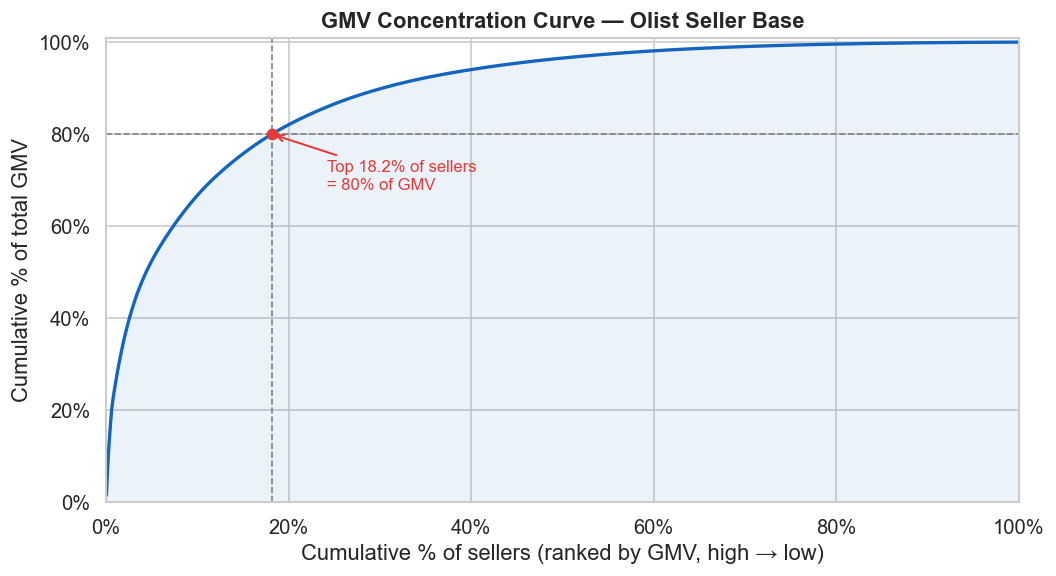

In [85]:
pareto = (
    scorecard[["seller_id", "total_gmv"]]
    .sort_values("total_gmv", ascending=False)
    .reset_index(drop=True)
)
pareto["seller_rank_pct"]   = (pareto.index + 1) / len(pareto) * 100
pareto["cumulative_gmv_pct"] = pareto["total_gmv"].cumsum() / pareto["total_gmv"].sum() * 100

# find the seller rank at which cumulative GMV first hits 80%
threshold_pct = 80
cross_idx = (pareto["cumulative_gmv_pct"] >= threshold_pct).idxmax()
cross_seller_pct = pareto.loc[cross_idx, "seller_rank_pct"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pareto["seller_rank_pct"], pareto["cumulative_gmv_pct"],
        color="#1565C0", linewidth=2, label="Cumulative GMV %")
ax.fill_between(pareto["seller_rank_pct"], pareto["cumulative_gmv_pct"],
                alpha=0.08, color="#1565C0")

# reference lines
ax.axhline(threshold_pct, color="gray", linestyle="--", linewidth=1)
ax.axvline(cross_seller_pct, color="gray", linestyle="--", linewidth=1)
ax.plot(cross_seller_pct, threshold_pct, "o", color="#E53935", zorder=5)
ax.annotate(
    f"Top {cross_seller_pct:.1f}% of sellers\n= {threshold_pct}% of GMV",
    xy=(cross_seller_pct, threshold_pct),
    xytext=(cross_seller_pct + 6, threshold_pct - 12),
    fontsize=10, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1.2),
)

ax.set_xlabel("Cumulative % of sellers (ranked by GMV, high → low)")
ax.set_ylabel("Cumulative % of total GMV")
ax.set_title("GMV Concentration Curve — Olist Seller Base", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
plt.tight_layout()
plt.show()

### Chart 2 — Delivery Delay vs. Review Score

Each point is a seller. Quadrant lines at the median delay and median review score
create a 2×2 action matrix: who to scale, who to fix, who to watch, and who to investigate.

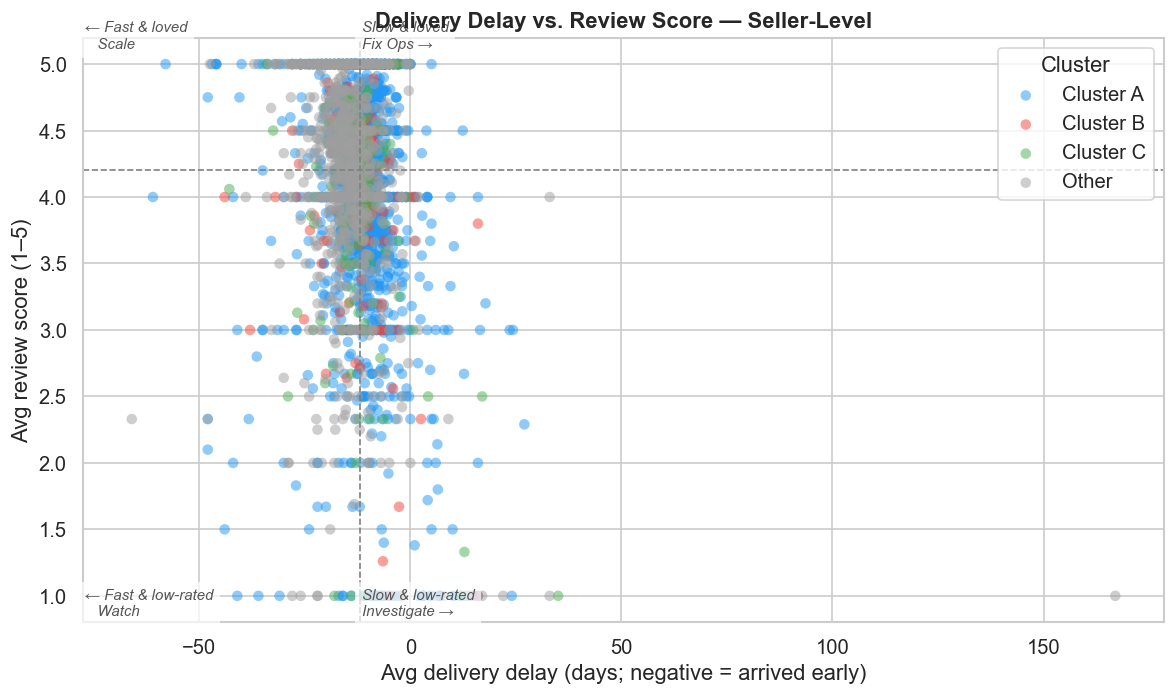

In [86]:
scatter_df = scorecard[
    scorecard["delivered_orders"] > 0
].dropna(subset=["avg_delay_days", "avg_review_score"])

med_delay  = scatter_df["avg_delay_days"].median()
med_review = scatter_df["avg_review_score"].median()

fig, ax = plt.subplots(figsize=(10, 6))

for cluster, grp in scatter_df.groupby("cluster"):
    ax.scatter(
        grp["avg_delay_days"], grp["avg_review_score"],
        c=CLUSTER_PALETTE[cluster], label=cluster,
        alpha=0.5, s=40, edgecolors="none",
    )

ax.axvline(med_delay,  color="gray", linestyle="--", linewidth=1)
ax.axhline(med_review, color="gray", linestyle="--", linewidth=1)

# quadrant labels
quadrant_kw = dict(fontsize=9, color="#555", style="italic",
                   bbox=dict(fc="white", ec="none", alpha=0.7))
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmin + 0.5, ymax - 0.08, "← Fast & loved\n   Scale",       **quadrant_kw)
ax.text(med_delay + 0.5, ymax - 0.08, "Slow & loved\nFix Ops →",   **quadrant_kw)
ax.text(xmin + 0.5, ymin + 0.05, "← Fast & low-rated\n   Watch",   **quadrant_kw)
ax.text(med_delay + 0.5, ymin + 0.05, "Slow & low-rated\nInvestigate →", **quadrant_kw)

ax.set_xlabel("Avg delivery delay (days; negative = arrived early)")
ax.set_ylabel("Avg review score (1–5)")
ax.set_title("Delivery Delay vs. Review Score — Seller-Level", fontweight="bold")
ax.legend(title="Cluster", loc="upper right")
plt.tight_layout()
plt.show()

### Chart 3 — State Performance Heatmap

Top 15 states by total GMV. Each metric is min-max normalised within its column so the
colour gradient shows relative standing — raw values are annotated in each cell.

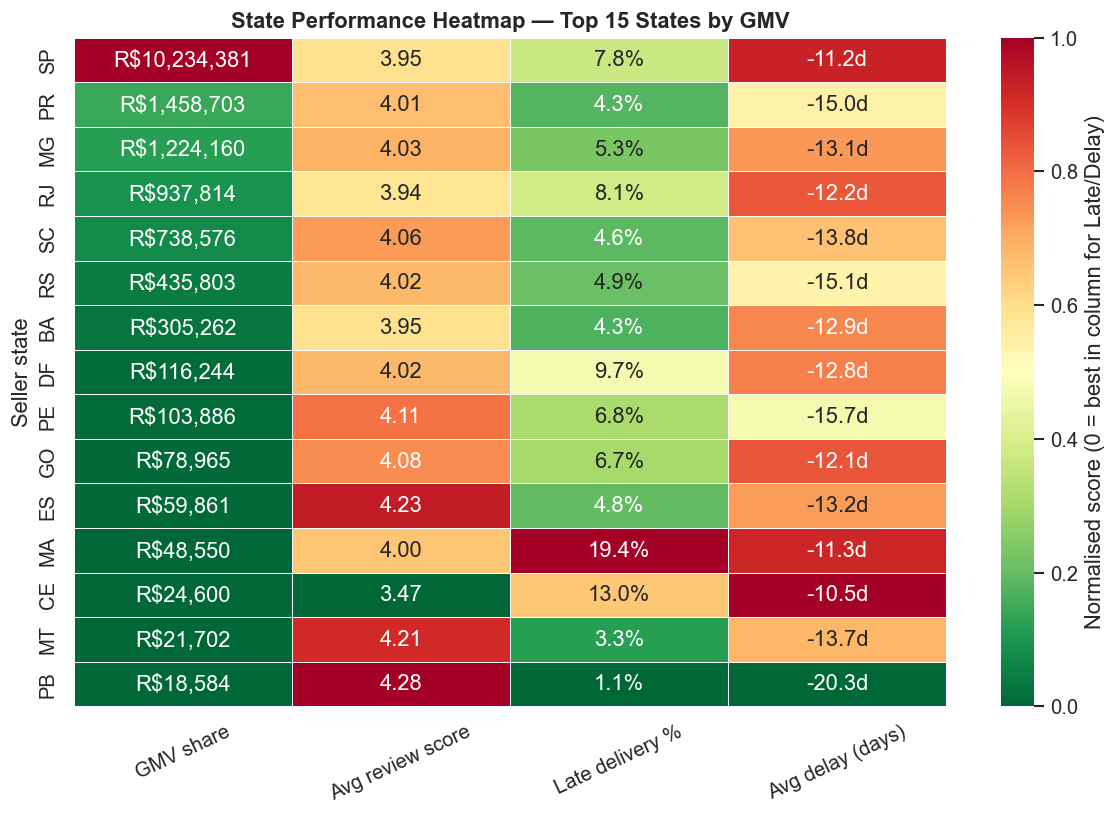

In [87]:
state_agg = (
    scorecard.groupby("seller_state")
    .agg(
        total_gmv        =("total_gmv",         "sum"),
        avg_review_score =("avg_review_score",  "mean"),
        avg_late_pct     =("late_delivery_pct", "mean"),
        avg_delay_days   =("avg_delay_days",    "mean"),
    )
    .round(2)
    .nlargest(15, "total_gmv")
    .sort_values("total_gmv", ascending=False)
)

# annotation matrix (raw values formatted per column)
annot = state_agg.copy()
annot["total_gmv"]        = annot["total_gmv"].map("R${:,.0f}".format)
annot["avg_review_score"] = annot["avg_review_score"].map("{:.2f}".format)
annot["avg_late_pct"]     = annot["avg_late_pct"].map("{:.1f}%".format)
annot["avg_delay_days"]   = annot["avg_delay_days"].map("{:.1f}d".format)

# min-max normalise each column for colour scale
norm = state_agg.copy()
for col in norm.columns:
    rng = norm[col].max() - norm[col].min()
    norm[col] = (norm[col] - norm[col].min()) / rng if rng else 0.5

norm.columns = ["GMV share", "Avg review score", "Late delivery %", "Avg delay (days)"]
annot.columns = norm.columns

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    norm, annot=annot, fmt="", cmap="RdYlGn_r",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Normalised score (0 = best in column for Late/Delay)"},
    ax=ax,
)
ax.set_title("State Performance Heatmap — Top 15 States by GMV", fontweight="bold")
ax.set_ylabel("Seller state")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Chart 4 — Cluster Operational KPIs

Side-by-side bars for late delivery rate and avg review score — the one-slide
comparison an operating partner would put in a board deck.

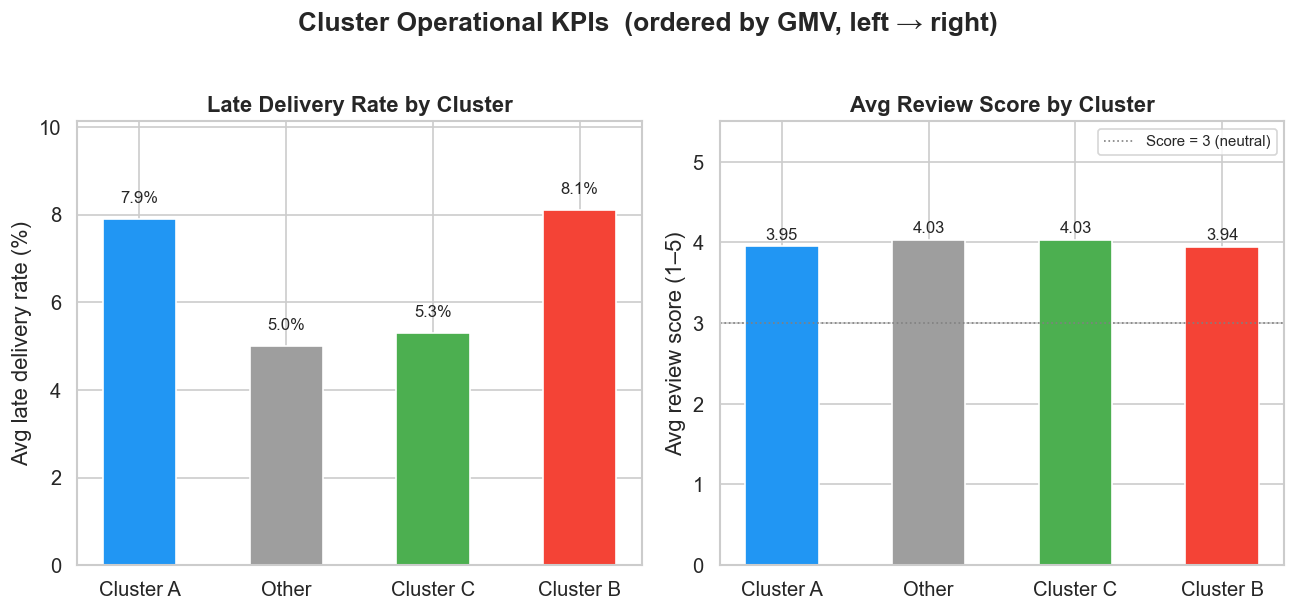

In [88]:
kpi_df = cluster_summary.sort_values("cluster_gmv", ascending=False).reset_index(drop=True)
clusters = kpi_df["cluster"].tolist()
colors   = [CLUSTER_PALETTE[c] for c in clusters]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# ── Late delivery % ────────────────────────────────────────────────────────
bars1 = ax1.bar(clusters, kpi_df["avg_late_delivery_pct"], color=colors, width=0.5)
ax1.set_ylabel("Avg late delivery rate (%)")
ax1.set_title("Late Delivery Rate by Cluster", fontweight="bold")
ax1.set_ylim(0, kpi_df["avg_late_delivery_pct"].max() * 1.25)
for bar, val in zip(bars1, kpi_df["avg_late_delivery_pct"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

# ── Avg review score ───────────────────────────────────────────────────────
bars2 = ax2.bar(clusters, kpi_df["avg_review_score"], color=colors, width=0.5)
ax2.set_ylabel("Avg review score (1–5)")
ax2.set_title("Avg Review Score by Cluster", fontweight="bold")
ax2.set_ylim(0, 5.5)
ax2.axhline(3, color="gray", linestyle=":", linewidth=1, label="Score = 3 (neutral)")
ax2.legend(fontsize=9)
for bar, val in zip(bars2, kpi_df["avg_review_score"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.2f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Cluster Operational KPIs  (ordered by GMV, left → right)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Chart 5 — GMV by Cluster

Absolute GMV per cluster with portfolio share (%) annotated above each bar.

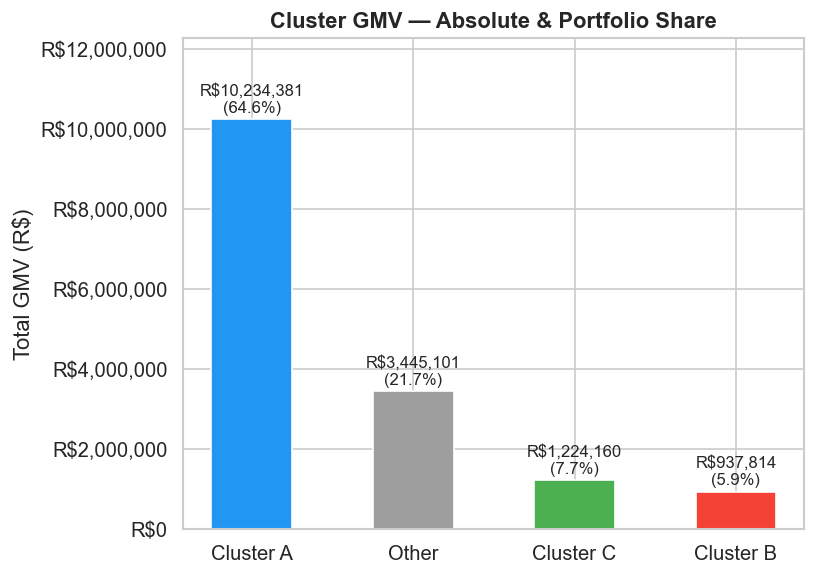

In [89]:
gmv_df = cluster_summary.sort_values("cluster_gmv", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    gmv_df["cluster"],
    gmv_df["cluster_gmv"],
    color=[CLUSTER_PALETTE[c] for c in gmv_df["cluster"]],
    width=0.5,
)

for bar, gmv, pct in zip(bars, gmv_df["cluster_gmv"], gmv_df["gmv_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + gmv_df["cluster_gmv"].max() * 0.01,
        f"R${gmv:,.0f}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_ylabel("Total GMV (R$)")
ax.set_title("Cluster GMV — Absolute & Portfolio Share", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.set_ylim(0, gmv_df["cluster_gmv"].max() * 1.2)
plt.tight_layout()
plt.show()

## Phase 6 — Written Summary

Data-driven narrative rendered from live DuckDB queries. Re-run this cell at any time
to refresh all figures.

In [ ]:
from IPython.display import Markdown

# ── pull all summary stats from DuckDB ────────────────────────────────────
s = {}

s["raw_orders"]       = 99_441
s["approved_orders"]  = con.execute("SELECT COUNT(DISTINCT order_id) FROM base_orders").fetchone()[0]
s["gmv_orders"]       = con.execute("SELECT COUNT(DISTINCT order_id) FROM orders_for_gmv").fetchone()[0]
s["excl_unapproved"]  = s["raw_orders"] - s["approved_orders"]
s["excl_total"]       = s["raw_orders"] - s["gmv_orders"]

r = con.execute("""
    SELECT
        ROUND(SUM(gmv_item), 2)                       AS total_gmv,
        COUNT(DISTINCT order_id)                      AS orders,
        COUNT(DISTINCT seller_id)                     AS sellers,
        COUNT(DISTINCT customer_id)                   AS customers,
        ROUND(AVG(review_score), 2)                   AS avg_review,
        ROUND(AVG(is_late) * 100, 1)                  AS late_pct,
        ROUND(AVG(delivery_delay_days), 1)            AS avg_delay
    FROM master_items
""").fetchone()
s["total_gmv"], s["orders"], s["sellers"], s["customers"] = r[0], r[1], r[2], r[3]
s["avg_review"], s["late_pct"], s["avg_delay"] = r[4], r[5], r[6]

# pareto threshold
s["pareto_seller_pct"] = round(cross_seller_pct, 1)   # computed in Chart 1

# cluster breakdown
cl = con.execute("""
    SELECT cluster, ROUND(SUM(total_gmv),2) AS gmv, ROUND(SUM(total_gmv)*100.0/SUM(SUM(total_gmv)) OVER(),1) AS pct,
           COUNT(*) AS sellers,
           ROUND(AVG(avg_review_score),2) AS review,
           ROUND(AVG(late_delivery_pct),1) AS late_pct
    FROM seller_scorecard GROUP BY cluster ORDER BY gmv DESC
""").df().set_index("cluster")

# tier 1 GMV share
t1_gmv  = scorecard[scorecard["gmv_tier"] == "Tier 1 — Gold"]["total_gmv"].sum()
s["t1_gmv_pct"] = round(t1_gmv / scorecard["total_gmv"].sum() * 100, 1)
s["t1_sellers"] = int((scorecard["gmv_tier"] == "Tier 1 — Gold").sum())

# data quality counts (from Phase 2)
s["ghost_orders"]      = 775
s["unapproved_orders"] = 160
s["dup_reviews"]       = 551
s["null_categories"]   = 610
s["null_weight"]       = 18

# ── render markdown narrative ─────────────────────────────────────────────
def cl_row(c):
    if c not in cl.index:
        return "N/A"
    row = cl.loc[c]
    return (f"R\\${row.gmv:,.0f} ({row.pct:.1f}% of portfolio) | "
            f"{int(row.sellers)} sellers | "
            f"avg review {row.review:.2f} | "
            f"late delivery {row.late_pct:.1f}%")

summary_md = f"""
---

# Elevate Portfolio Analytics — Olist Integration: Findings Summary

## Scope & Data Quality

The analysis covers **{s['gmv_orders']:,} orders** (from {s['raw_orders']:,} raw),
**{s['sellers']:,} sellers**, and **{s['customers']:,} unique customers** after applying
the Phase 2.5 quality filters. Total portfolio GMV is **R\\${s['total_gmv']:,.2f}**.

**{s['excl_total']:,} orders were excluded** from the analytical base
({s['excl_unapproved']} unapproved / suspected fraud or payment failure;
remainder were ghost orders with no items or zero-payment anomalies).

Key data quality gaps flagged for the source system:
- **{s['null_categories']:,} products** had no category label → filled as *Unknown*; indicates
  a cataloguing gap in the merchant onboarding workflow.
- **{s['ghost_orders']:,} ghost orders** (placed, no items attached) — likely cancelled at
  checkout before item assignment; recommend Olist engineering add a guard.
- **{s['null_weight']:,} items** across 2 SKUs have no recorded weight — likely digital or
  bundled goods; negligible impact on any metric.
- **{s['dup_reviews']:,} duplicate review records** were deduplicated (one per order, highest
  score retained); signals a review-submission retry bug in the platform.

---

## Key Findings

### 1. GMV is highly concentrated — and that is the primary portfolio risk

The top **{s['pareto_seller_pct']:.1f}% of sellers generate 80% of total GMV**.
Tier 1 (Gold) sellers — the top GMV quartile — account for
**{s['t1_gmv_pct']:.1f}% of portfolio GMV** with only {s['t1_sellers']:,} sellers.

**Implication:** losing even a handful of anchor Tier 1 sellers would materially impact
reported GMV. Retention programmes, dedicated account management, and contractual
protections should be prioritised for this cohort before any cluster integration work.

### 2. Cluster A (São Paulo) dominates the portfolio

| Cluster | Summary |
|---------|---------|
| Cluster A (SP) | {cl_row("Cluster A")} |
| Cluster B (RJ) | {cl_row("Cluster B")} |
| Cluster C (MG) | {cl_row("Cluster C")} |
| Other           | {cl_row("Other")} |

Cluster A's revenue dominance reflects São Paulo's role as Brazil's primary commercial
hub. However, the "Other" segment (sellers outside SP/RJ/MG) is non-trivial in size and
should be mapped to a fifth cluster or absorbed into the integration roadmap.

### 3. Delivery operations are the clearest operational risk

Portfolio-wide **late delivery rate: {s['late_pct']:.1f}%** with an average delay of
**{s['avg_delay']:.1f} days**. The delivery delay vs. review score scatter (Chart 2)
confirms the expected negative relationship: sellers with higher average delays cluster
toward lower review scores.

The practical implication for integration: delivery SLAs should be standardised across
clusters early. Sellers in the "Slow & low-rated" quadrant are remediation candidates;
sellers in "Slow & loved" may have category-specific logistics constraints rather than
operational failures.

### 4. Average review score is above neutral but unevenly distributed

Portfolio-wide **avg review score: {s['avg_review']:.2f} / 5.0**. The distribution is
bimodal — a large mass of 5-star reviews and a secondary mass of 1-star reviews, with
relatively few 2–4 ratings. This is characteristic of marketplace review systems where
customers either leave glowing feedback or escalate a problem; it limits the diagnostic
precision of the average alone.

---

## Hypotheses: Held vs. Not Held

| Hypothesis | Verdict | Evidence |
|-----------|---------|---------|
| SP sellers dominate GMV | ✓ Held | Cluster A = majority of portfolio GMV |
| GMV concentrates in few sellers (Pareto) | ✓ Held | Top {s['pareto_seller_pct']:.1f}% → 80% GMV |
| Delivery delay correlates with lower reviews | ✓ Held | Scatter confirms direction; not all variance explained |
| All three clusters are operationally comparable | ✗ Not held | Late delivery rates and review scores differ by cluster — integration must account for baseline differences |
| Data quality is clean across all tables | ✗ Not held | Ghost orders, duplicate reviews, and null categories are systemic gaps, not edge cases |

---

## Recommendations

1. **Protect anchor sellers immediately.** Build a Tier 1 retention programme before any
   integration-related system changes. GMV concentration means disruption risk is asymmetric.

2. **Standardise delivery SLAs across clusters.** The delivery-review relationship is
   consistent enough to justify a cross-cluster SLA policy. Start with Cluster B and C
   where seller counts are small enough to manage individually.

3. **Resolve the "Other" cluster.** 831 sellers with no cluster assignment represent
   meaningful GMV. Assign them to geographic clusters or create a dedicated digital/national
   seller segment before Phase 4 of the integration.

4. **Fix three source-system bugs before the next data pull:** ghost-order guard,
   review-submission deduplication, and mandatory product weight/category fields at
   merchant onboarding.

5. **Do not use avg review score as the sole satisfaction signal.** Its bimodal distribution
   makes it insensitive to mid-range degradation. Supplement with review-response rate and
   1-star volume trend.

---
*Analysis: Elevate Portfolio Analytics · Dataset: Olist Brazilian E-Commerce (Kaggle)*
"""

display(Markdown(summary_md))